In [1]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, PolynomialFeatures, StandardScaler, OneHotEncoder
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import catboost
from catboost import CatBoostClassifier
import optuna 
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, classification_report
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier
import lightgbm as lgb

In [2]:
train = pd.read_parquet('train.parquet')
test = pd.read_parquet('test.parquet')
val = pd.read_parquet('val.parquet')
target1 = 'Target1'
target2 = 'Target2'

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 591285 entries, 963695 to 636609
Data columns (total 21 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Age             551055 non-null  float64
 1   Ind_Household   591285 non-null  object 
 2   Age_group       591285 non-null  object 
 3   District        591285 non-null  object 
 4   Region          591285 non-null  object 
 5   Lifetime        583726 non-null  float64
 6   Income          591285 non-null  int64  
 7   Segment         591285 non-null  object 
 8   Ind_deposit     591285 non-null  object 
 9   Ind_email       591285 non-null  object 
 10  Ind_phone       591285 non-null  object 
 11  Ind_salary      591285 non-null  object 
 12  trans_6_month   591285 non-null  float64
 13  trans_9_month   591285 non-null  float64
 14  trans_12_month  591285 non-null  float64
 15  amont_trans     591285 non-null  int64  
 16  amont_day_from  591285 non-null  int64  
 17  trans_3_mo

In [3]:
train = train.drop(columns=['Ind_Household', 'Region', 'Ind_deposit', 'Ind_email', 'Ind_phone', 'Ind_salary', 'trans_6_month', 'trans_9_month', 'trans_12_month', 'amont_trans'])
val = val.drop(columns=['Ind_Household', 'Region', 'Ind_deposit', 'Ind_email', 'Ind_phone', 'Ind_salary', 'trans_6_month', 'trans_9_month', 'trans_12_month', 'amont_trans'])
test = test.drop(columns=['Ind_Household', 'Region', 'Ind_deposit', 'Ind_email', 'Ind_phone', 'Ind_salary', 'trans_6_month', 'trans_9_month', 'trans_12_month', 'amont_trans'])




In [5]:
train

,Age,Age_group,District,Lifetime,Income,Segment,amont_day_from,trans_3_month,Gender,Target1,Target2
963695,73.0,senior,09,4.0,53,Gold,24,961.780000,M,1,1
759675,37.0,middle,52,4.0,58,Silver,28,935.174529,F,1,0
245217,NaN,unknown,03,16.0,49,Silver,15,991.400000,U,0,0
71316,51.0,middle,53,5.0,55,Tin,15,969.010000,F,0,0
256377,44.0,middle,03,7.0,40,Gold,16,927.500000,F,0,0
...,...,...,...,...,...,...,...,...,...,...,...
906602,52.0,middle,49,8.0,55,Gold,14,960.200000,M,0,0
829155,62.0,senior,32,2.0,46,Gold,13,984.400000,F,0,0
459940,69.0,senior,42,8.0,44,Platinum,14,974.060000,M,0,0
296417,76.0,senior,50,8.0,50,Gold,14,929.980000,M,0,0


# Catboost

In [6]:
cat_features = train.select_dtypes(include=['object', 'category']).columns.tolist()

In [7]:
cat_features

['Age_group', 'District', 'Segment', 'Gender']

In [8]:
model = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=3, random_seed=42)
model.fit(train.drop(columns=[target1, target2]), train[target2], cat_features=cat_features, eval_set = (val.drop(columns=[target1, target2]), val[target2]), verbose=100)



0:	learn: 0.5728332	test: 0.5729921	best: 0.5729921 (0)	total: 160ms	remaining: 2m 40s
100:	learn: 0.1165419	test: 0.1171183	best: 0.1171183 (100)	total: 8.27s	remaining: 1m 13s
200:	learn: 0.1026052	test: 0.1031100	best: 0.1031100 (200)	total: 16s	remaining: 1m 3s
300:	learn: 0.0969331	test: 0.0974034	best: 0.0974034 (300)	total: 23.8s	remaining: 55.3s
400:	learn: 0.0935413	test: 0.0939701	best: 0.0939701 (400)	total: 31.6s	remaining: 47.2s
500:	learn: 0.0921690	test: 0.0926176	best: 0.0926176 (500)	total: 39.4s	remaining: 39.3s
600:	learn: 0.0909483	test: 0.0914110	best: 0.0914110 (600)	total: 47.5s	remaining: 31.5s
700:	learn: 0.0904328	test: 0.0909254	best: 0.0909254 (700)	total: 55.7s	remaining: 23.8s
800:	learn: 0.0898217	test: 0.0903195	best: 0.0903195 (800)	total: 1m 3s	remaining: 15.9s
900:	learn: 0.0893740	test: 0.0898752	best: 0.0898752 (900)	total: 1m 12s	remaining: 7.92s
999:	learn: 0.0889122	test: 0.0894283	best: 0.0894283 (999)	total: 1m 20s	remaining: 0us

bestTest = 0.

In [9]:
print(f"TRAIN : {roc_auc_score(train[target2], model.predict_proba(train.drop(columns=[target1, target2]))[:, 1])}")
print(f"VAL : {roc_auc_score(val[target2], model.predict_proba(val.drop(columns=[target1, target2]))[:, 1])}")
print(f"TEST : {roc_auc_score(test[target2], model.predict_proba(test.drop(columns=[target1, target2]))[:, 1])}")

TRAIN : 0.9809324571818437
VAL : 0.9808016772841122
TEST : 0.9815979333507756


In [10]:
print(classification_report(test[target2], model.predict(test.drop(columns=[target1, target2]))))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98    180178
           1       0.87      0.71      0.79     16918

    accuracy                           0.97    197096
   macro avg       0.92      0.85      0.88    197096
weighted avg       0.96      0.97      0.97    197096



# Decision tree

In [4]:
for col in train.select_dtypes(include='number').columns:
    train[col].fillna(train[col].median(), inplace=True)

for col in train.select_dtypes(include='object').columns:
    train[col].fillna(train[col].mode()[0], inplace=True)




for col in val.select_dtypes(include='number').columns:
    val[col].fillna(val[col].median(), inplace=True)

for col in val.select_dtypes(include='object').columns:
    val[col].fillna(val[col].mode()[0], inplace=True)



for col in test.select_dtypes(include='number').columns:
    test[col].fillna(test[col].median(), inplace=True)

for col in test.select_dtypes(include='object').columns:
    test[col].fillna(test[col].mode()[0], inplace=True)

    


train_new = pd.get_dummies(train, drop_first=True)
val_new = pd.get_dummies(val, drop_first=True)
test_new = pd.get_dummies(test, drop_first=True)

/var/folders/_k/vxqnb8117qb_1tpg9p98mtyc0000gn/T/ipykernel_44265/2452799383.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train[col].fillna(train[col].median(), inplace=True)
/var/folders/_k/vxqnb8117qb_1tpg9p98mtyc0000gn/T/ipykernel_44265/2452799383.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values 

In [12]:
model = DecisionTreeClassifier(random_state=42)
model.fit(train_new.drop(columns=['Target1', 'Target2']), train_new['Target2'])

DecisionTreeClassifier(random_state=42)

In [13]:
print(f"TRAIN : {roc_auc_score(train_new[target2], model.predict_proba(train_new.drop(columns=[target1, target2]))[:, 1])}")
print(f"VAL : {roc_auc_score(val_new[target2], model.predict_proba(val_new.drop(columns=[target1, target2]))[:, 1])}")
print(f"TEST : {roc_auc_score(test_new[target2], model.predict_proba(test_new.drop(columns=[target1, target2]))[:, 1])}")

TRAIN : 1.0
VAL : 0.8525484660547142
TEST : 0.8547816714136088


In [14]:
y_pred = model.predict(test_new.drop(columns=['Target1', 'Target2']))
y_proba = model.predict_proba(test_new.drop(columns=['Target1', 'Target2']))[:, 1]

accuracy = accuracy_score(test_new['Target2'], y_pred)

print(f'Accuracy: {accuracy:.3f}')

Accuracy: 0.955


In [15]:
f1 = f1_score(test_new['Target2'], y_pred)
print(f'F1 Score: {f1:.3f}')

F1 Score: 0.737


# Logistict Regression 

In [16]:
model = LogisticRegression()
model.fit(train_new.drop(columns=[target1, target2]), train_new[target2])

/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [17]:
print(f"TRAIN : {roc_auc_score(train_new[target2], model.predict_proba(train_new.drop(columns=[target1, target2]))[:, 1])}")
print(f"VAL : {roc_auc_score(val_new[target2], model.predict_proba(val_new.drop(columns=[target1, target2]))[:, 1])}")
print(f"TEST : {roc_auc_score(test_new[target2], model.predict_proba(test_new.drop(columns=[target1, target2]))[:, 1])}")

TRAIN : 0.7406816185009986
VAL : 0.7437495506692797
TEST : 0.7403553322532973


In [18]:
print(f"TRAIN : {f1_score(train_new[target2], model.predict(train_new.drop(columns=[target1, target2])))}")
print(f"VAL : {f1_score(val_new[target2], model.predict(val_new.drop(columns=[target1, target2])))}")
print(f"TEST : {f1_score(test_new[target2], model.predict(test_new.drop(columns=[target1, target2])))}")

TRAIN : 0.0010672991402312481
VAL : 0.0005868200222991608
TEST : 0.0014135940629049358


In [19]:
y_pred = model.predict(test_new.drop(columns=[target1, target2]))

accuracy = accuracy_score(test_new[target2], y_pred)
precision = precision_score(test_new[target2], y_pred)
recall = recall_score(test_new[target2], y_pred)

print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.91
Precision: 0.20
Recall: 0.00


# Random Forest

In [20]:
model = RandomForestClassifier(random_state=42)
model.fit(train_new.drop(columns=['Target1', 'Target2']), train_new['Target2'])

RandomForestClassifier(random_state=42)

In [21]:
print(f"TRAIN : {roc_auc_score(train_new[target2], model.predict_proba(train_new.drop(columns=[target1, target2]))[:, 1])}")
print(f"VAL : {roc_auc_score(val_new[target2], model.predict_proba(val_new.drop(columns=[target1, target2]))[:, 1])}")
print(f"TEST : {roc_auc_score(test_new[target2], model.predict_proba(test_new.drop(columns=[target1, target2]))[:, 1])}")

TRAIN : 0.9999999999267133
VAL : 0.9611945993629345
TEST : 0.9611425669009549


In [22]:
y_pred = model.predict(test_new.drop(columns=['Target1', 'Target2']))
y_proba = model.predict_proba(test_new.drop(columns=['Target1', 'Target2']))[:, 1]

accuracy = accuracy_score(test_new['Target2'], y_pred)

print(f'Accuracy: {accuracy:.3f}')

Accuracy: 0.949


In [23]:
f1 = f1_score(test_new['Target2'], y_pred)
print(f'F1 Score: {f1:.3f}')

F1 Score: 0.606


# XGBoost

In [24]:
dtrain = xgb.DMatrix(train_new.drop(columns=[target1, target2]), label=train_new[target2])
dval = xgb.DMatrix(val_new.drop(columns=[target1, target2]), label=val_new[target2])
dtest = xgb.DMatrix(test_new.drop(columns=[target1, target2]), label=test_new[target2])

params = {
    'eta': 0.1,
    'max_depth': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'seed': 42
}

evals = [(dtrain, 'train'), (dval, 'val')]
model = xgb.train(params, 
                  dtrain, 
                  num_boost_round=100, 
                  evals=evals,
                  early_stopping_rounds=10,
                  verbose_eval=10)

[0]	train-rmse:0.27513	val-rmse:0.27653
[10]	train-rmse:0.25221	val-rmse:0.25343
[20]	train-rmse:0.23819	val-rmse:0.23933
[30]	train-rmse:0.21790	val-rmse:0.21882
[40]	train-rmse:0.20661	val-rmse:0.20738
[50]	train-rmse:0.19967	val-rmse:0.20032
[60]	train-rmse:0.19401	val-rmse:0.19461
[70]	train-rmse:0.18948	val-rmse:0.19007
[80]	train-rmse:0.18705	val-rmse:0.18764
[90]	train-rmse:0.18515	val-rmse:0.18575
[99]	train-rmse:0.18369	val-rmse:0.18427


In [25]:
y_pred_prob = model.predict(dtest)
y_pred = (y_pred_prob > 0.5).astype(int)

def print_metrics(y_true, y_pred, y_pred_prob):
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-score:", f1_score(y_true, y_pred))
    print("ROC-AUC:", roc_auc_score(y_true, y_pred_prob))

print("\nTest set metrics:")
print_metrics(test_new[target2], y_pred, y_pred_prob)

print("\nTrain set metrics:")
y_train_pred_prob = model.predict(dtrain)
y_train_pred = (y_train_pred_prob > 0.5).astype(int)
print_metrics(train_new[target2], y_train_pred, y_train_pred_prob)

print("\nValidation set metrics:")
y_val_pred_prob = model.predict(dval)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)
print_metrics(val_new[target2], y_val_pred, y_val_pred_prob)


Test set metrics:
Accuracy: 0.9592381377602792
Precision: 0.8821403991741225
Recall: 0.6061000118217283
F1-score: 0.7185200756779483
ROC-AUC: 0.9670724349152141

Train set metrics:
Accuracy: 0.9589047582806938
Precision: 0.8762548540198476
Recall: 0.6037059056678558
F1-score: 0.7148841302434732
ROC-AUC: 0.9654873174101918

Validation set metrics:
Accuracy: 0.9588474651946259
Precision: 0.8783496384517226
Recall: 0.6071386569446078
F1-score: 0.7179861618163486
ROC-AUC: 0.9652108924368816


# LightGBM

In [5]:
train_data = lgb.Dataset(train_new.drop(columns=[target1, target2]), label=train_new[target2])
val_data = lgb.Dataset(val_new.drop(columns=[target1, target2]), label=val_new[target2], reference=train_data)

params = {
    'objective': 'binary',           # Задача бинарной классификации
    'boosting_type': 'gbdt',         # Тип бустинга
    'learning_rate': 0.05,           # Скорость обучения
    'num_leaves': 31,                # Количество листьев в дереве решений
    'max_depth': -1,                 # Максимальная глубина дерева (-1 — не ограничено)
    'verbose': -1,                   
    'random_state': 42
}

model = lgb.train(
    params,
    train_data,
    valid_sets=[val_data],
    num_boost_round=1000
)

Accuracy на тесте: 0.9708
              precision    recall  f1-score   support

           0       0.98      0.99      0.98    180178
           1       0.89      0.75      0.82     16918

    accuracy                           0.97    197096
   macro avg       0.93      0.87      0.90    197096
weighted avg       0.97      0.97      0.97    197096

ROC-AUC Score на тесте: 0.9874


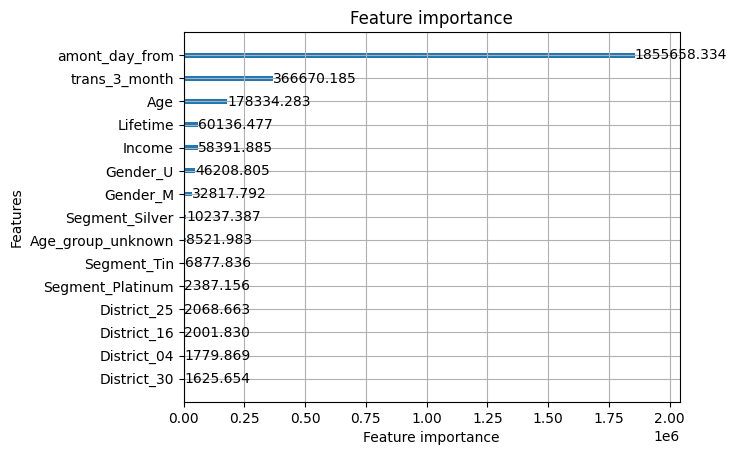

In [7]:
y_pred_prob = model.predict(test_new.drop(columns=[target1, target2]), num_iteration=model.best_iteration)
y_pred = (y_pred_prob > 0.5).astype(int)  # Преобразование вероятностей в метки классов

accuracy = accuracy_score(test_new[target2], y_pred)
print(f'Accuracy на тесте: {accuracy:.4f}')
print(classification_report(test_new[target2], y_pred))

lgb.plot_importance(model, max_num_features=15, importance_type='gain')

y_pred_prob = model.predict(test_new.drop(columns=[target1, target2]), num_iteration=model.best_iteration)

roc_auc = roc_auc_score(test_new[target2], y_pred_prob)
print(f'ROC-AUC Score на тесте: {roc_auc:.4f}')